In [163]:
import pandas as pd
import numpy as np
from numba import njit
import matplotlib.pyplot as plt

In [164]:
# Загрузка исторических данных

# name = "BTCUSDT_1h_last_year"
# filename = f"data/1h_last_year/{name}.csv"
name = "BTCUSDT_1h_10_years"
filename = f"data/1h_10_years/{name}.csv"
data = pd.read_csv(filename, parse_dates=['timestamp'])
data.set_index('timestamp', inplace=True)
# data = data['2025-03-29 06:00:00':]
data.drop(['high', 'low', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore'], axis=1, inplace=True)

In [165]:
# Стратегия

short_window = 200
long_window = 50

data['SMA200'] = data['close'].rolling(window=short_window).mean()
data['SMA50'] = data['close'].rolling(window=long_window).mean()

# Сигналы для покупки
data['buy'] = np.where((data['SMA50'] >= data['SMA200']) & (data['SMA50'].shift(1) <= data['SMA200'].shift(1)), 1, 0)

# Сигналы для продажи
data['sell'] = np.where((data['SMA50'] <= data['SMA200']) & (data['SMA50'].shift(1) >= data['SMA200'].shift(1)), -1, 0)

data['signal'] = data['buy'] + data['sell']

In [166]:
price = data['open'].values.astype(np.float64)
signal = data['signal'].values.astype(np.int8)

In [167]:
@njit
def execute_strategy(open_price, signal,
                     initial_cash=100000.0,
                     buy_pct=0.6,
                     commission=0.001,
                     lot_size=0.0001):

    n = len(open_price)

    cash = initial_cash
    shares = 0

    equity = np.zeros(n)
    cash_arr = np.zeros(n)
    shares_arr = np.zeros(n)

    equity[0] = initial_cash
    cash_arr[0] = cash
    shares_arr[0] = 0

    for i in range(1, n):
        p = open_price[i]
        prev_signal = signal[i-1]

        # --- BUY ---
        if prev_signal == 1:

            # расчет позиции на сделку
            target_value = cash * buy_pct

            # перевод в лоты
            shares_to_buy = np.floor(target_value / p / lot_size) * lot_size

            cost = shares_to_buy * p
            fee = cost * commission

            if cost + fee <= cash and shares_to_buy > 0:
                cash -= (cost + fee)
                shares += shares_to_buy

        # --- SELL ---
        elif prev_signal == -1:
            shares_to_sell = shares  # продаём всё (можно частично)

            if shares_to_sell > 0:
                proceeds = shares_to_sell * p
                fee = proceeds * commission

                cash += (proceeds - fee)
                shares = 0

        # --- учёт состояния ---
        cash_arr[i] = cash
        shares_arr[i] = shares
        equity[i] = cash + shares * p

    return equity, cash_arr, shares_arr

equity, cash, shares = execute_strategy(price, signal)

portfolio = pd.DataFrame(index=data.index)

portfolio['price'] = price
portfolio['signal'] = signal
portfolio['cash'] = cash
portfolio['shares'] = shares
portfolio['equity'] = equity
portfolio['2025-07-23': '2025-08-15'].head(60)
portfolio.tail(20)


,price,signal,cash,shares,equity
timestamp,,,,,
2026-04-12 14:00:00,70889.42,0,211745.544869,4.6043,538141.701375
2026-04-12 15:00:00,70748.34,0,211745.544869,4.6043,537492.126731
2026-04-12 16:00:00,70892.04,0,211745.544869,4.6043,538153.764641
2026-04-12 17:00:00,70936.27,0,211745.544869,4.6043,538357.412830
2026-04-12 18:00:00,71140.51,0,211745.544869,4.6043,539297.795062
2026-04-12 19:00:00,71137.65,0,211745.544869,4.6043,539284.626764
2026-04-12 20:00:00,71084.18,0,211745.544869,4.6043,539038.434843
2026-04-12 21:00:00,71335.43,0,211745.544869,4.6043,540195.265218
2026-04-12 22:00:00,71364.03,0,211745.544869,4.6043,540326.948198


In [168]:
import time

start_time = time.perf_counter()  # или time.time()
equity, cash, shares = execute_strategy(price, signal)
end_time = time.perf_counter()

print(f"Время выполнения: {end_time - start_time:.6f} секунд")


Время выполнения: 0.001185 секунд


In [169]:
len(equity)

75742

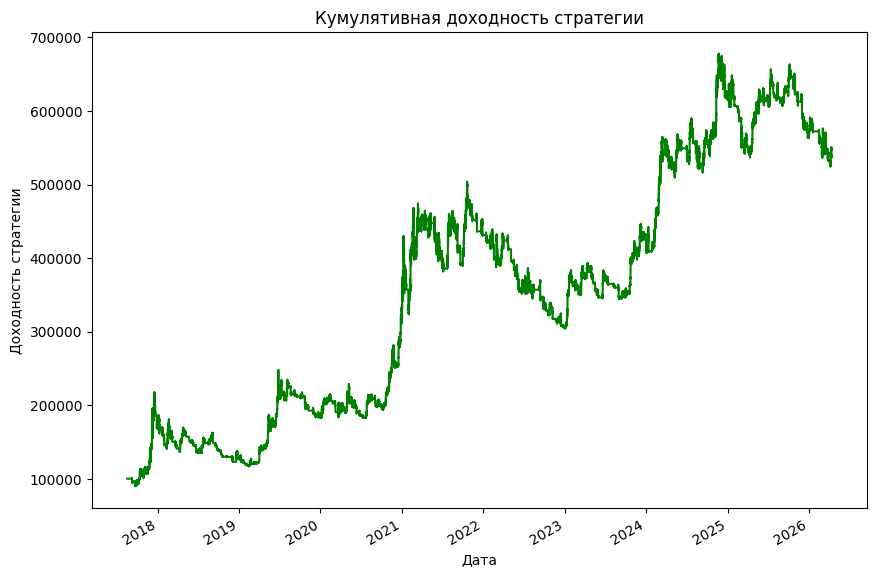

In [170]:
portfolio['equity'].plot(figsize=(10, 7), color='green')
plt.title('Кумулятивная доходность стратегии')
plt.xlabel('Дата')
plt.ylabel('Доходность стратегии')
plt.show()